# 02 · House prices over a decade — CSO Residential Property Price Index (HPM09)

**Primary dataset of this project.** CSO PxStat table **HPM09 — Residential Property Price Index (RPPI)**, monthly **Jan 2005 → Jun 2026**, national / Dublin / NUTS3 regional series, base year **2015 = 100**. This notebook covers the *past 10 years* of the Irish housing market (**2016 → mid-2026**) with the crash-and-recovery context since 2005.

API endpoint: `https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/HPM09/JSON-stat/2.0/en`

In [1]:
# %% setup
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'data'
DER = DATA / 'derived'
CHARTS = ROOT / 'charts'
CHARTS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10, 'axes.titlesize': 11,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True,
})

def savefig(fig, name):
    fig.savefig(CHARTS / name, bbox_inches='tight')
    plt.show()
    plt.close(fig)

IRISH = ['#169b62', '#00b2a9', '#004d3a', '#9d9fa2', '#ff8300', '#4b6e91', '#d3261e']

In [2]:
# %% load the primary dataset (HPM09 monthly RPPI, 2005-2026)
rppi = pd.read_csv(DER / 'rppi_monthly_index.csv')
rppi['date'] = pd.to_datetime(rppi['date'])
rppi['year'] = rppi['period'].str[:4].astype(int)
rppi = rppi.sort_values(['series', 'date']).reset_index(drop=True)
print('rows:', len(rppi), '| months:', rppi['period'].nunique(), '| series:', rppi['series'].nunique())
print()
for s in rppi['series'].unique():
    print('  -', s)

rows: 4500 | months: 258 | series: 20

  - Border - houses
  - Dublin - all residential properties
  - Dublin - apartments
  - Dublin - houses
  - Dublin City - houses
  - Dun Laoghaire-Rathdown - houses
  - Fingal - houses
  - Mid-East - houses
  - Mid-West - houses
  - Midland - houses
  - National - all residential properties
  - National - apartments
  - National - houses
  - National excluding Dublin - all residential properties
  - National excluding Dublin - apartments
  - National excluding Dublin - houses
  - South Dublin - houses
  - South-East - houses
  - South-West - houses
  - West - houses


In [3]:
# %% annual average index (2015 = 100) - base for decade growth
nat = rppi[rppi['series'] == 'National - all residential properties']
annual = pd.DataFrame({
    'year': nat.groupby('year')['index'].mean().index,
    'national_index': nat.groupby('year')['index'].mean().values,
    'yoy_avg': nat.groupby('year')['pct_12m'].mean().values,
})
print(annual[annual.year.between(2011, 2026)].round(2).to_string(index=False))
d = nat[nat['period'].isin(['2016-01', '2016-12', '2025-12', '2026-06'])]
print('\nIndex at selected dates:')
print(d[['period', 'index']].round(1).to_string(index=False))

 year  national_index  yoy_avg
 2011           87.87   -17.17
 2012           76.02   -13.07
 2013           76.99     1.24
 2014           89.71    16.43
 2015           99.98    11.74
 2016          107.47     7.45
 2017          119.14    10.83
 2018          131.34    10.32
 2019          134.41     2.37
 2020          134.83     0.30
 2021          145.98     8.25
 2022          163.95    12.44
 2023          168.98     3.09
 2024          183.38     8.51
 2025          197.19     7.55
 2026          205.43     6.42

Index at selected dates:
 period  index
2016-01  104.0
2016-12  112.2
2025-12  204.4
2026-06  206.9


In [4]:
# %% five price phases of the decade (national index, 2015=100)
phase_bounds = [
    ('2015-12', '2018-08', 'Recovery boom I'),
    ('2018-08', '2020-05', 'Cooling + Covid pause'),
    ('2020-05', '2022-05', 'Pandemic boom II'),
    ('2022-05', '2023-10', 'Rate-shock slowdown'),
    ('2023-10', '2026-06', 'Re-acceleration'),
]
nat_ts = nat.set_index('date')['index'].sort_index()
rows = []
for a, b, name in phase_bounds:
    va = float(nat_ts.loc[pd.Timestamp(a + '-01')])
    vb = float(nat_ts.loc[pd.Timestamp(b + '-01')])
    rows.append(dict(phase=name, from_month=a, to_month=b, index_start=round(va, 1),
                     index_end=round(vb, 1), change_pct=round((vb / va - 1) * 100, 1)))
print(pd.DataFrame(rows).to_string(index=False))
yoy = nat.set_index('date')['pct_12m']
d10 = yoy['2016-01':'2026-06']
print('\ndecade YoY max = %.1f%% (%s) | min = %.1f%% (%s)' % (
    d10.max(), d10.idxmax().strftime('%Y-%m'), d10.min(), d10.idxmin().strftime('%Y-%m')))
print('nominal national index +100.9%% between Dec-2015 and Jun-2026')

                phase from_month to_month  index_start  index_end  change_pct
      Recovery boom I    2015-12  2018-08        103.0      133.1        29.2
Cooling + Covid pause    2018-08  2020-05        133.1      134.1         0.8
     Pandemic boom II    2020-05  2022-05        134.1      161.7        20.6
  Rate-shock slowdown    2022-05  2023-10        161.7      171.9         6.3
      Re-acceleration    2023-10  2026-06        171.9      206.9        20.4

decade YoY max = 15.1% (2022-02) | min = -0.9% (2020-08)
nominal national index +100.9%% between Dec-2015 and Jun-2026


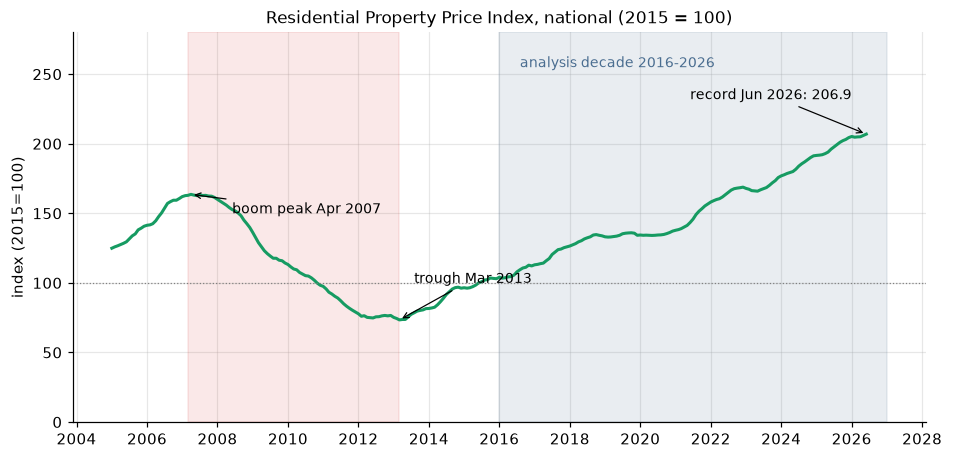

In [5]:
# %% FIG 1 - national index 2005-2026, analysis decade shaded
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(nat_ts.index, nat_ts.values, lw=2, color=IRISH[0])
ax.axvspan(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'), color=IRISH[5], alpha=0.12)
ax.axvspan(pd.Timestamp('2007-03-01'), pd.Timestamp('2013-03-01'), color='#d3261e', alpha=0.10)
ax.axhline(100, color='grey', lw=0.8, ls=':')
ax.annotate('boom peak Apr 2007', xy=(pd.Timestamp('2007-04-01'), 163.6), xytext=(pd.Timestamp('2008-06-01'), 150),
            arrowprops=dict(arrowstyle='->', lw=0.8), fontsize=9)
ax.annotate('trough Mar 2013', xy=(pd.Timestamp('2013-03-01'), 73.4), xytext=(pd.Timestamp('2013-08-01'), 100),
            arrowprops=dict(arrowstyle='->', lw=0.8), fontsize=9)
ax.annotate('record Jun 2026: 206.9', xy=(pd.Timestamp('2026-06-01'), 206.9), xytext=(pd.Timestamp('2021-06-01'), 232),
            arrowprops=dict(arrowstyle='->', lw=0.8), fontsize=9)
ax.text(pd.Timestamp('2016-08-01'), 255, 'analysis decade 2016-2026', fontsize=9, color=IRISH[5])
ax.set_title('Residential Property Price Index, national (2015 = 100)')
ax.set_ylabel('index (2015=100)')
ax.set_ylim(0, 280)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
savefig(fig, 'fig1_rppi_national_2005_2026.png')

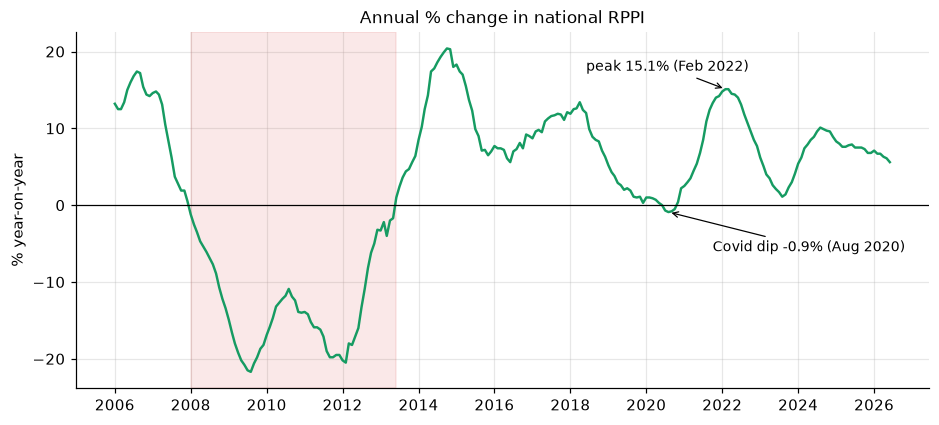

In [6]:
# %% FIG 2 - year-on-year change
fig, ax = plt.subplots(figsize=(10, 4.2))
y = yoy.loc[yoy.index >= pd.Timestamp('2006-01-01')]
ax.plot(y.index, y.values, lw=1.6, color=IRISH[0])
ax.axhline(0, color='black', lw=0.8)
ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2013-06-01'), color='#d3261e', alpha=0.10)
ax.annotate('peak 15.1% (Feb 2022)', xy=(pd.Timestamp('2022-02-01'), 15.1), xytext=(pd.Timestamp('2018-06-01'), 17.5),
            arrowprops=dict(arrowstyle='->', lw=0.8), fontsize=9)
ax.annotate('Covid dip -0.9% (Aug 2020)', xy=(pd.Timestamp('2020-08-01'), -0.9), xytext=(pd.Timestamp('2021-10-01'), -6),
            arrowprops=dict(arrowstyle='->', lw=0.8), fontsize=9)
ax.set_title('Annual % change in national RPPI')
ax.set_ylabel('% year-on-year')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
savefig(fig, 'fig2_rppi_national_yoy.png')

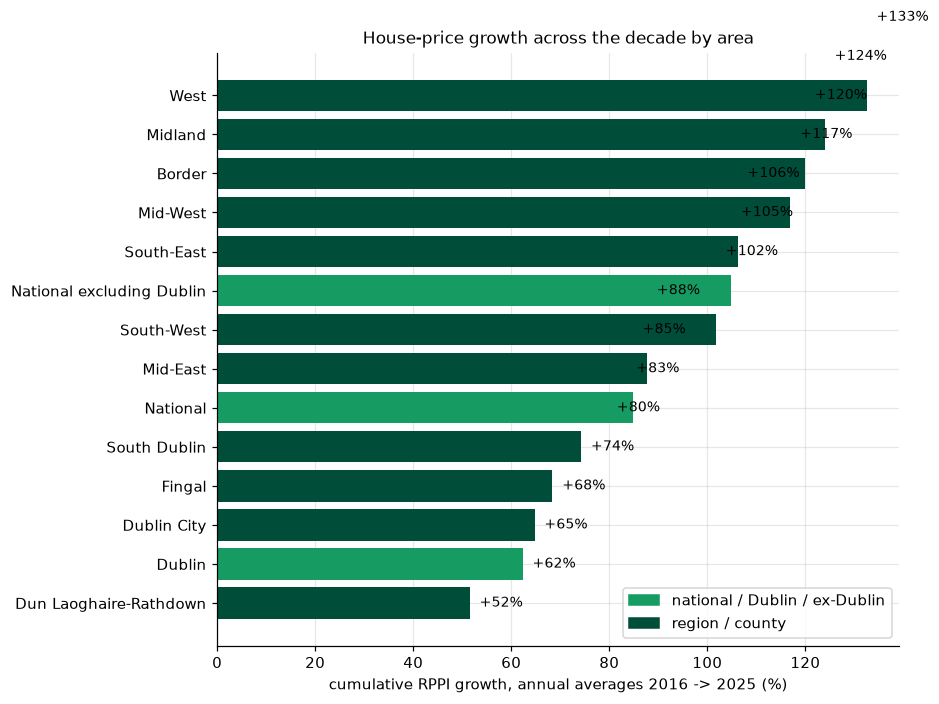

region
Dun Laoghaire-Rathdown        51.5
Dublin                        62.3
Dublin City                   64.8
Fingal                        68.4
South Dublin                  74.3
National                      79.5
National                      83.5
National                      84.8
Mid-East                      87.7
South-West                   101.8
National excluding Dublin    104.8
South-East                   106.2
Mid-West                     117.0
Border                       119.9
Midland                      124.0
West                         132.5


In [7]:
# %% decade growth by area - annual averages 2016 vs 2025
focus = ['National - all residential properties', 'National - houses', 'National - apartments',
         'Dublin - all residential properties', 'National excluding Dublin - all residential properties']
names, g = [], []
for lab in focus:
    s = rppi[rppi['series'] == lab]
    a = s.groupby('year')['index'].mean()
    names.append(lab.split(' - ')[0])
    g.append((a.loc[2025] / a.loc[2016] - 1) * 100)
for lab in ['Dublin City - houses', 'Dun Laoghaire-Rathdown - houses', 'Fingal - houses', 'South Dublin - houses']:
    s = rppi[rppi['series'] == lab]
    a = s.groupby('year')['index'].mean()
    names.append(lab.replace(' - houses', ''))
    g.append((a.loc[2025] / a.loc[2016] - 1) * 100)
for lab in ['Border - houses', 'Midland - houses', 'West - houses', 'Mid-East - houses',
            'Mid-West - houses', 'South-East - houses', 'South-West - houses']:
    s = rppi[rppi['series'] == lab]
    a = s.groupby('year')['index'].mean()
    names.append(lab.replace(' - houses', ''))
    g.append((a.loc[2025] / a.loc[2016] - 1) * 100)
reg = pd.DataFrame({'region': names, 'growth_2016_25': g}).set_index('region').sort_values('growth_2016_25')

fig, ax = plt.subplots(figsize=(8, 7))
cols = [IRISH[0] if r in ('National', 'National excluding Dublin', 'Dublin') else IRISH[2] for r in reg.index]
ax.barh(reg.index, reg['growth_2016_25'], color=cols)
for i, v in enumerate(reg['growth_2016_25']):
    ax.text(v + 2, i, '%+.0f%%' % v, va='center', fontsize=9)
ax.set_xlabel('cumulative RPPI growth, annual averages 2016 -> 2025 (%)')
ax.set_title('House-price growth across the decade by area')
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=IRISH[0], label='national / Dublin / ex-Dublin'),
                   plt.Rectangle((0, 0), 1, 1, color=IRISH[2], label='region / county')], loc='lower right')
savefig(fig, 'fig3_regional_growth_2016_25.png')
print(reg['growth_2016_25'].round(1).to_string())

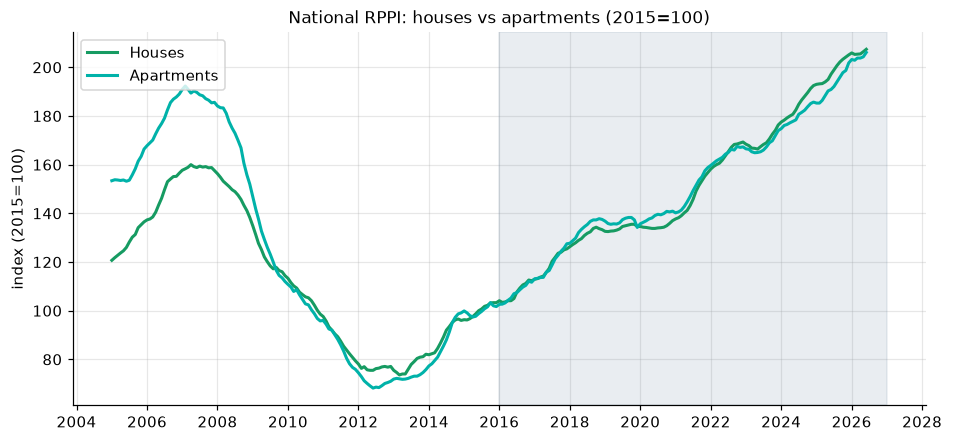

In [8]:
# %% houses vs apartments (national)
fig, ax = plt.subplots(figsize=(10, 4.4))
for lab, c in [('National - houses', IRISH[0]), ('National - apartments', IRISH[1])]:
    s = rppi[rppi['series'] == lab].set_index('date').sort_index()
    ax.plot(s.index, s['index'], lw=2, color=c, label=lab.split(' - ')[-1].title())
ax.axvspan(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'), color=IRISH[5], alpha=0.12)
ax.set_title('National RPPI: houses vs apartments (2015=100)')
ax.legend(loc='upper left')
ax.set_ylabel('index (2015=100)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
savefig(fig, 'fig4_houses_vs_apartments.png')

/tmp/ipykernel_10644/2818240264.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  joint = pd.concat([r, cpi_m], axis=1, keys=['rppi', 'cpi']).dropna()


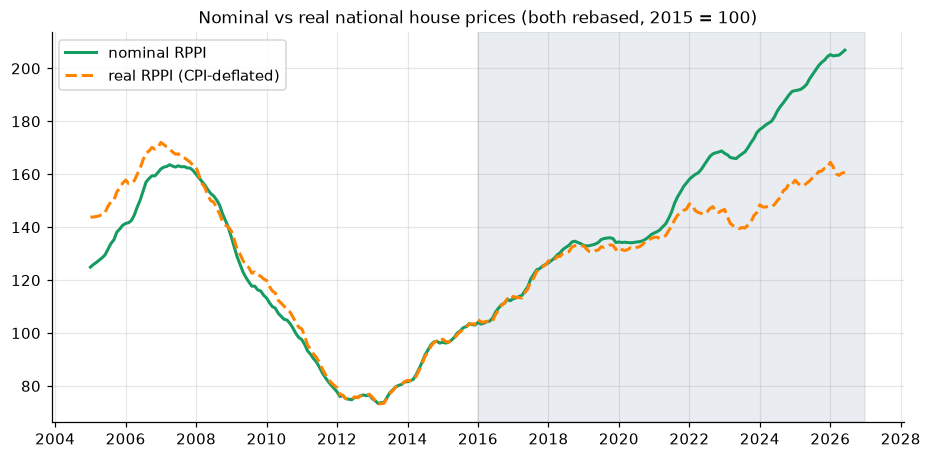

real national index Q1-2016 104.5 -> Q4-2025 161.9  (+55.0%)


In [9]:
# %% nominal vs real (CPI-deflated, both rebased 2015 = 100)
cpi = pd.read_csv(DATA / 'processed' / 'cpm24_cpi_allitems_monthly.csv')
cpi['date'] = pd.to_datetime(cpi['date'])
cpi_m = cpi.set_index('date')['cpi_2015=100']
r = nat.set_index('date')['index']
joint = pd.concat([r, cpi_m], axis=1, keys=['rppi', 'cpi']).dropna()
real = (joint['rppi'] / joint['cpi'] * 100.0)
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(joint.index, joint['rppi'], color=IRISH[0], lw=2, label='nominal RPPI')
ax.plot(real.index, real.values, color=IRISH[4], lw=2, ls='--', label='real RPPI (CPI-deflated)')
ax.axvspan(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'), color=IRISH[5], alpha=0.12)
ax.set_title('Nominal vs real national house prices (both rebased, 2015 = 100)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
savefig(fig, 'fig5_nominal_vs_real.png')
q16 = float(real.loc['2016-01-01':'2016-03-31'].mean())
q25 = float(real.loc['2025-10-01':'2025-12-31'].mean())
print('real national index Q1-2016 %.1f -> Q4-2025 %.1f  (%+.1f%%)' % (q16, q25, (q25 / q16 - 1) * 100))

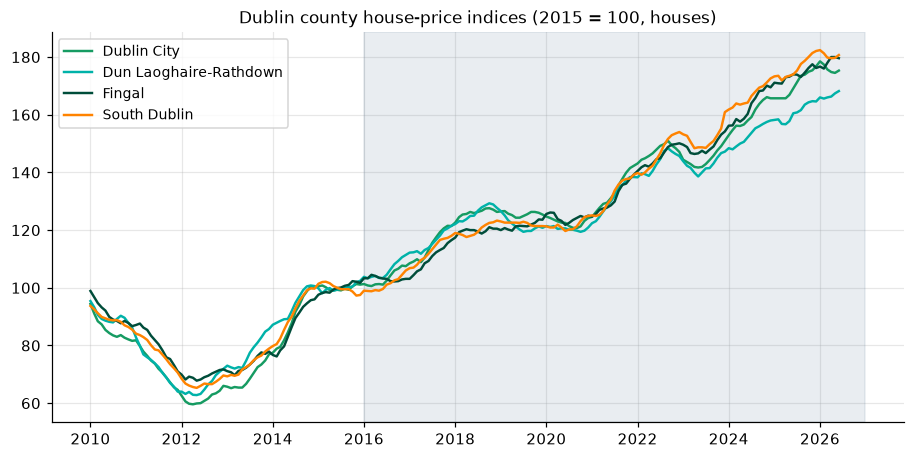

In [10]:
# %% Dublin county house indices
fig, ax = plt.subplots(figsize=(10, 4.6))
dubc = ['Dublin City - houses', 'Dun Laoghaire-Rathdown - houses', 'Fingal - houses', 'South Dublin - houses']
for lab, c in zip(dubc, [IRISH[0], IRISH[1], IRISH[2], IRISH[4]]):
    s = rppi[rppi['series'] == lab].set_index('date').sort_index()
    ax.plot(s.index, s['index'], lw=1.6, color=c, label=lab.replace(' - houses', ''))
ax.axvspan(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'), color=IRISH[5], alpha=0.12)
ax.set_title('Dublin county house-price indices (2015 = 100, houses)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
savefig(fig, 'fig6_dublin_counties.png')

# Decade findings — prices (computed from CSO HPM09 monthly data)

1. **A price doubling in a decade.** The national RPPI (2015 = 100) averaged **107.5 in 2016** and **197.2 in 2025**
   (+**83.5%**; ≈7.0% p.a. compound). By June 2026 the index was **206.9** — more than double December 2015
   (+101%) and ≈26% above the pre-crash 2007 peak in nominal, quality-adjusted terms.

2. **Five distinct phases** since end-2015:
   - *Recovery boom I* (Dec 2015 → Aug 2018): **+29%**
   - *Cooling + Covid pause* (Aug 2018 → May 2020): **+0.8%**
   - *Pandemic boom II* (May 2020 → May 2022): **+21%**, YoY peaking at **15.1%** (Feb 2022)
   - *Rate-shock slowdown* (May 2022 → Oct 2023): **+6%**
   - *Re-acceleration* (Oct 2023 → Jun 2026): **+20%**
   The only negative year-on-year prints of the decade were the short Covid dip (min **-0.9%**, Aug 2020).

3. **Dublin led early; the regions caught up dramatically.** Ex-Dublin prices rose **+105%** over 2016–2025 versus
   **+62%** in Dublin. Regional houses gained West **+133%**, Midland **+124%**, Border **+120%**, Mid-West **+117%**,
   South-East **+106%**, South-West **+102%**, Mid-East **+88%**; Dublin counties **+57–70%**.

4. **Houses vs apartments**: national houses **+85%** vs apartments **+79%** (annual-average 2016→2025).

5. **Real prices rose ≈55%** — CPI (2015 = 100) reached ≈125 by end-2025, so house prices grew roughly **+55% in real
   terms** between Q1-2016 and Q4-2025, far outpacing the cost of living.

6. **Drivers visible in the data**: post-crash demand recovery (2016–19); Covid pause (2020); ultra-cheap-money boom
   (2021–22); ECB rate shock (2022–23 slowdown); and renewed boom (2024–26) as the chronic supply shortage persisted.